# 16 · Is head-FT better than No-FT? Library level, similar molecules, and confidence across seeds

Three questions, answered separately because the answers differ.

1. **Whole library:** does fine-tuning find more actives, discard more inactives, or trade one for the other?
2. **Similar molecules:** when two near-identical molecules have different outcomes, does head-FT tell them apart better than No-FT?
3. **Confidence:** across the five fine-tuning runs (seeds), do similar molecules get consistent, confident predictions?

**On ground truth.** The only real label is binary (active or inactive). For similar molecules, a *true large delta* is a pair of near-identical molecules whose label flips (a **cliff**, one active and one inactive); a *true absence of a delta* is a near-identical pair where both are active (**conserved**). There is no potency for the inactives, so no magnitude of the true delta is claimed. Each model's own notion of 'large' is calibrated on the conserved pairs (see section 2), so the comparison does not depend on any score scale.

In [1]:

import json, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")
from IPython.display import display
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; CL="#d62728"; CO="#2a78d6"; NEU="#666666"; GRN="#1baf7a"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); A=ROOT/"results/analysis/588689/cliffs"
P=pd.read_csv(A/"pairs.csv"); M=pd.read_csv(A/"compounds.csv"); Z=np.load(A/"contacts.npz",allow_pickle=True)
AU=pd.read_csv(A/"modality_auroc.csv").set_index("modality")
MODS=[("score_boltz2","Boltz-2 (dataset score)"),("base_noft","Boltz-2 No-FT (our pipeline)"),
      ("ft300","Boltz-2 head-FT N=300 (5-seed)"),("score_boltzina","Boltzina"),
      ("score_boltzina_recycle1","Boltzina recycle-1"),("score_boltzina_mask","Boltzina mask"),
      ("docking_score_boltzina","Boltzina docking (3 identical columns)"),("score_gnina","GNINA"),("score_vina","AutoDock Vina")]
MN=dict(MODS)
CONF=[("ligand_iptm","ligand ipTM (= ipTM here)"),("complex_plddt","complex pLDDT"),("confidence_score","overall confidence"),
      ("complex_pde","complex PDE"),("disagree_noft","two-head disagreement (No-FT)"),("disagree_ft300","two-head disagreement (FT)"),
      ("cross_seed_sd","cross-seed SD (FT)")]
Mi=M.set_index("id"); rng=np.random.default_rng(0)
# ---- orient pairs: a = the ACTIVE member for cliffs; controls (both active) get a random a/b orientation
flip=(P.kind=="conserved")&(rng.random(len(P))<0.5)
swaps=[("id_a","id_b"),("smiles_a","smiles_b"),("diff_a_atoms","diff_b_atoms"),("mcs_a","mcs_b"),("ia","ib")]
swaps+=[(c,"b_"+c[2:]) for c in P.columns if c.startswith("a_") and ("b_"+c[2:]) in P.columns]
for x,y in swaps:
    tmp=P.loc[flip,x].copy(); P.loc[flip,x]=P.loc[flip,y].values; P.loc[flip,y]=tmp.values
def side(col,ids): return Mi[col].reindex(ids).values
for m,_ in MODS: P["d_"+m]=side("pct_"+m,P.id_a)-side("pct_"+m,P.id_b)
for f,_ in CONF: P["c_"+f]=side(f,P.id_a)-side(f,P.id_b)
rowof={i:k for k,i in enumerate(Z["ids"])}; MD=Z["mind"]
ma=MD[[rowof[i] for i in P.id_a]]; mb=MD[[rowof[i] for i in P.id_b]]
ca_,cb_=(ma<=5.0),(mb<=5.0)
inter=(ca_&cb_).sum(1); uni=(ca_|cb_).sum(1)
P["pose_jdist"]=np.where(np.isnan(ma).any(1)|np.isnan(mb).any(1),np.nan,1-inter/np.maximum(uni,1))
P["pose_absdiff"]=np.nanmean(np.abs(ma-mb),axis=1)
PROPS=[("MW","molecular weight"),("heavy","heavy atoms"),("logP","logP"),("TPSA","polar surface area"),("HBD","H-bond donors"),
       ("HBA","H-bond acceptors"),("rotb","rotatable bonds"),("arom_rings","aromatic rings"),("fsp3","fraction sp3")]
for p,_ in PROPS: P["dp_"+p]=P["a_"+p]-P["b_"+p]
_raw=pd.read_csv(ROOT/"data/mf-pcba_test/588689.csv"); ZS=pd.Series(_raw["SD Z-score"].values,index="588689_"+_raw.CID.astype(str))
ACT_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==1]; INA_Z=ZS[_raw.set_index("588689_"+_raw.CID.astype(str)).target_active_v2==0]
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
_ids=pd.unique(np.concatenate([P.id_a.values,P.id_b.values])); _ix={k:i for i,k in enumerate(_ids)}
_g=coo_matrix((np.ones(len(P)),([_ix[i] for i in P.id_a],[_ix[i] for i in P.id_b])),shape=(len(_ids),len(_ids)))
_nc,_lab=connected_components(_g,directed=False); P["series"]=[_lab[_ix[i]] for i in P.id_a]
P["simbin"]=pd.cut(P.sim,[0.6,0.7,0.8,1.01],labels=["0.60-0.70","0.70-0.80",">=0.80"],right=False)
_sz=P[P.kind=="cliff"].groupby("series").size().sort_values(ascending=False); BIG=_sz.index[0]; P["big"]=P.series==BIG
CLIFF=P[P.kind=="cliff"].copy(); CTRL=P[P.kind=="conserved"].copy()
def clus_acc(df,col,B=2000,seed=0,neg=False):
    """share of pairs where the signal ranks the active higher (ties = 0.5), 95% CI from resampling chemical SERIES
    (pairs that share an active or sit in the same chemical series are not independent; a series = a connected cluster of pairs)"""
    x=(-df[col] if neg else df[col]).values.astype(float); ids=df["series"].values; ok=np.isfinite(x); x,ids=x[ok],ids[ok]
    if len(x)==0: return np.nan,np.nan,np.nan,0,0
    ind=np.where(x>0,1.0,np.where(x==0,0.5,0.0)); u,inv=np.unique(ids,return_inverse=True)
    sm=np.bincount(inv,weights=ind); n=np.bincount(inv).astype(float)
    idx=np.random.default_rng(seed).integers(0,len(u),(B,len(u))); bs=sm[idx].sum(1)/n[idx].sum(1)
    return sm.sum()/n.sum(),np.percentile(bs,2.5),np.percentile(bs,97.5),int(n.sum()),len(u)
print(f"{P.series.nunique()} independent chemical series (connected clusters of pairs); {CLIFF.series.nunique()} contain a cliff")
print(f"pairs: {len(CLIFF)} cliff (active + inactive), {len(CTRL)} conserved controls (both active); "
      f"{CLIFF.id_a.nunique()} distinct actives have a cliff partner")

S=pd.read_csv(A/"scores_seeds_eval.csv").set_index("id"); SEEDS=[f"ft_p{s}" for s in range(5)]
S["ft_mean"]=S[SEEDS].mean(axis=1); N=len(S); y=S.label.values; NPOS=int(y.sum())
lg=lambda p: np.log(np.clip(p,1e-6,1-1e-6)/(1-np.clip(p,1e-6,1-1e-6)))
S["ft_dis"]=S[[f"ft_dis{s}" for s in range(5)]].mean(axis=1); S["ft_sd"]=lg(S[SEEDS].values).std(1,ddof=1)
MEM=pd.unique(np.concatenate([P.id_a,P.id_b]))
CAL=pd.read_csv(A/"ft_vs_noft_calibrated.csv")
NOFT,FT_="No-FT","head-FT (5-seed mean)"
print(f"library (held-out eval set): {N:,} compounds, {NPOS} active, {N-NPOS:,} inactive")
print(f"similar molecules: {len(CLIFF)} cliff pairs (label flips) and {len(CTRL)} conserved pairs (both active), {len(MEM)} distinct compounds, {CLIFF.id_a.nunique()} actives with a cliff partner, {P.series.nunique()} chemical series")


94 independent chemical series (connected clusters of pairs); 73 contain a cliff
pairs: 406 cliff (active + inactive), 275 conserved controls (both active); 114 distinct actives have a cliff partner
library (held-out eval set): 49,685 compounds, 396 active, 49,289 inactive
similar molecules: 406 cliff pairs (label flips) and 275 conserved pairs (both active), 365 distinct compounds, 114 actives with a cliff partner, 94 chemical series


## 1. Whole library: sensitivity, specificity, precision
At the same number of compounds flagged, and at the default probability threshold of 0.5. Sensitivity is the share of the 396 actives found; specificity the share of inactives correctly left out; precision the share of flagged compounds that are active. FN means missed actives.

In [2]:
def conf(pred):
    tp=int((pred&(y==1)).sum()); fp=int((pred&(y==0)).sum()); fn=NPOS-tp; tn=(N-NPOS)-fp
    return dict(flagged=int(pred.sum()),TP=tp,FP=fp,FN=fn,TN=tn,sensitivity=tp/NPOS,specificity=tn/(N-NPOS),precision=tp/max(1,tp+fp))
MODELS=[(NOFT,"noft_p"),(FT_,"ft_mean")]; rows=[]
for lab,frac in [("top 0.5%",0.005),("top 1%",0.01),("top 2%",0.02),("top 5%",0.05),("top 10%",0.10)]:
    k=int(round(frac*N))
    for mn,col in MODELS:
        thr=np.sort(S[col].values)[::-1][k-1]; rows.append(dict(cutoff=lab,model=mn,**conf(S[col].values>=thr)))
for mn,col in MODELS: rows.append(dict(cutoff="probability > 0.5",model=mn,**conf(S[col].values>0.5)))
T1=pd.DataFrame(rows); display(T1.round(4).set_index(["cutoff","model"]))

flagged   TP    FP   FN     TN  \
cutoff            model                                                   
top 0.5%          No-FT                      248   42   206  354  49083   
                  head-FT (5-seed mean)      248   84   164  312  49125   
top 1%            No-FT                      497   67   430  329  48859   
                  head-FT (5-seed mean)      497  125   372  271  48917   
top 2%            No-FT                      994  117   877  279  48412   
                  head-FT (5-seed mean)      994  169   825  227  48464   
top 5%            No-FT                     2484  202  2282  194  47007   
                  head-FT (5-seed mean)     2484  253  2231  143  47058   
top 10%           No-FT                     4968  272  4696  124  44593   
                  head-FT (5-seed mean)     4968  314  4654   82  44635   
probability > 0.5 No-FT                     2062  190  1872  206  47417   
                  head-FT (5-seed mean)      200   75   125  321  49164   

                                         sensitivity  specificity  precision  
cutoff            model                                                       
top 0.5%          No-FT                       0.1061       0.9958     0.1694  
                  head-FT (5-seed mean)       0.2121       0.9967     0.3387  
top 1%            No-FT                       0.1692       0.9913     0.1348  
                  head-FT (5-seed mean)       0.3157       0.9925     0.2515  
top 2%            No-FT                       0.2955       0.9822     0.1177  
                  head-FT (5-seed mean)       0.4268       0.9833     0.1700  
top 5%            No-FT                       0.5101       0.9537     0.0813  
                  head-FT (5-seed mean)       0.6389       0.9547     0.1019  
top 10%           No-FT                       0.6869       0.9047     0.0548  
                  head-FT (5-seed mean)       0.7929       0.9056     0.0632  
probability > 0.5 No-FT                       0.4798       0.9620     0.0921  
                  head-FT (5-seed mean)       0.1894       0.9975     0.3750

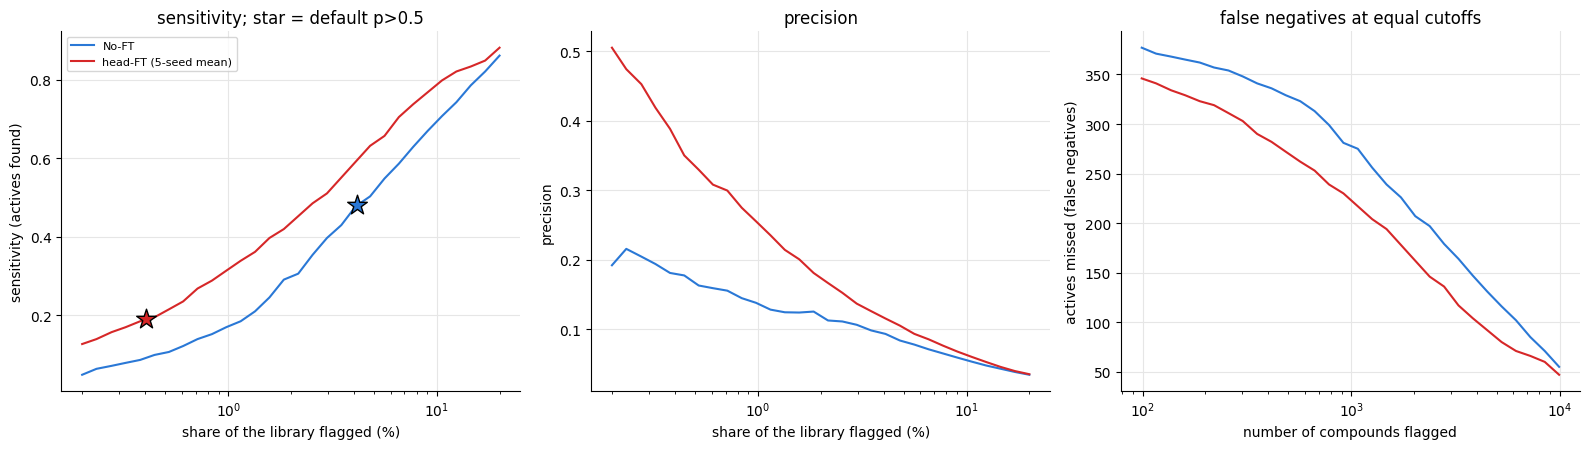

No-FT: at p>0.5 flags 2062 compounds, finds 190 of 396 actives, misses 206, false positives 1872
head-FT (5-seed mean): at p>0.5 flags 200 compounds, finds 75 of 396 actives, misses 321, false positives 125


In [3]:
ks=np.unique(np.round(np.geomspace(0.002,0.2,30)*N).astype(int)); fig,axes=plt.subplots(1,3,figsize=(16,4.6)); STAR={}
for (mn,col),c in zip(MODELS,[CO,CL]):
    order=np.argsort(-S[col].values); cs=np.cumsum(y[order]); rec=cs[ks-1]/NPOS; prec=cs[ks-1]/ks
    axes[0].plot(100*ks/N,rec,color=c,label=mn); axes[1].plot(100*ks/N,prec,color=c,label=mn); axes[2].plot(ks,NPOS-cs[ks-1],color=c,label=mn)
    r=conf(S[col].values>0.5); STAR[mn]=r; axes[0].scatter(100*r["flagged"]/N,r["sensitivity"],marker="*",s=220,color=c,edgecolor=BLK,zorder=5)
axes[0].set_xscale("log"); axes[1].set_xscale("log"); axes[2].set_xscale("log")
axes[0].set_xlabel("share of the library flagged (%)"); axes[0].set_ylabel("sensitivity (actives found)"); axes[0].set_title("sensitivity; star = default p>0.5"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("share of the library flagged (%)"); axes[1].set_ylabel("precision"); axes[1].set_title("precision")
axes[2].set_xlabel("number of compounds flagged"); axes[2].set_ylabel("actives missed (false negatives)"); axes[2].set_title("false negatives at equal cutoffs")
plt.tight_layout(); plt.show()
for mn in STAR: print(f"{mn}: at p>0.5 flags {STAR[mn]['flagged']} compounds, finds {STAR[mn]['TP']} of {NPOS} actives, misses {STAR[mn]['FN']}, false positives {STAR[mn]['FP']}")

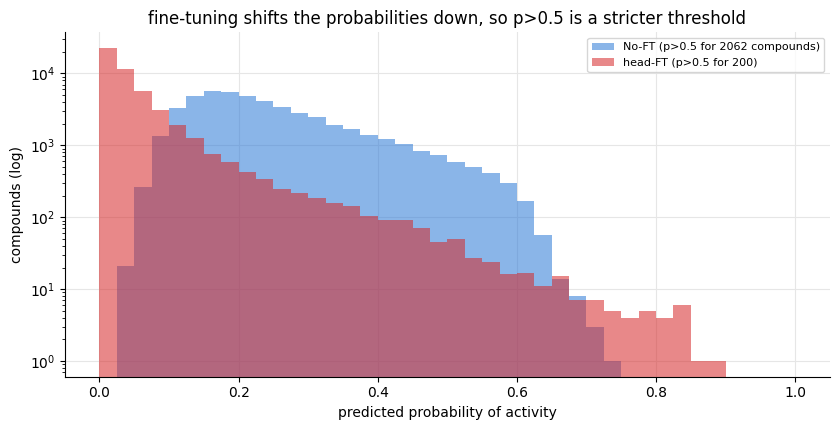

In [4]:
fig,ax=plt.subplots(figsize=(8.5,4.4)); bins=np.linspace(0,1,41)
ax.hist(S.noft_p,bins=bins,alpha=0.55,color=CO,label=f"No-FT (p>0.5 for {int((S.noft_p>0.5).sum())} compounds)"); ax.hist(S.ft_mean,bins=bins,alpha=0.55,color=CL,label=f"head-FT (p>0.5 for {int((S.ft_mean>0.5).sum())})")
ax.set_yscale("log"); ax.set_xlabel("predicted probability of activity"); ax.set_ylabel("compounds (log)"); ax.legend(fontsize=8); ax.set_title("fine-tuning shifts the probabilities down, so p>0.5 is a stricter threshold")
plt.tight_layout(); plt.show()

## 2. Similar molecules: is head-FT better at telling a near-identical pair apart?
Ground truth is the label flip. For each model the delta is the score of the active minus the score of its inactive partner. The conserved pairs (both active, random orientation) give each model's noise floor: a delta counts as 'large' if it exceeds the 90th (or 95th) percentile of |delta| among conserved pairs, so a model that spreads its scores more widely is not rewarded for it. **Sensitivity** is then the share of true cliffs whose delta clears that bar in the right direction. Everything is done on two score scales (percentile rank and log-odds) so the answer does not hinge on one transformation, and intervals resample independent chemical series, paired between the two models.

,n_cliff,n_conserved,n_series
subset,,,
all pairs,406,275,94
without the dominant series,154,196,93
dominant series only,252,79,1


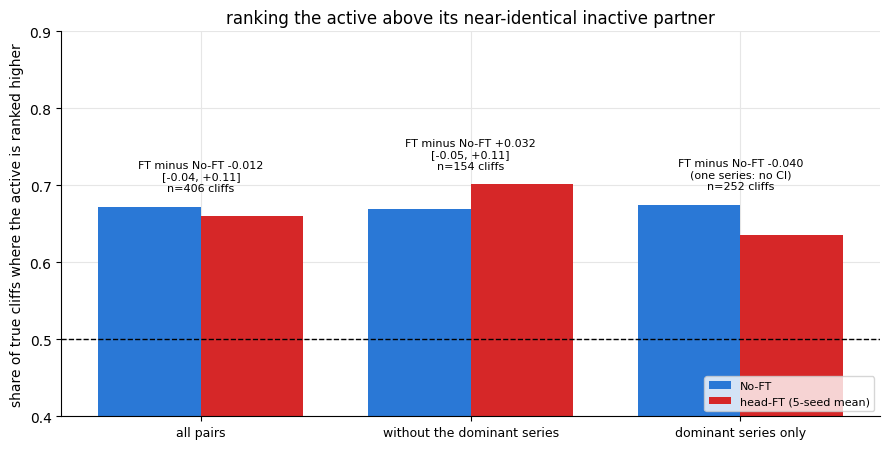

In [5]:
nn=CAL.drop_duplicates("subset")[["subset","n_cliff","n_conserved","n_series"]].set_index("subset"); display(nn)
pw=CAL[(CAL.metric=="pairwise_acc")&(CAL.scale=="percentile")].set_index("subset").loc[["all pairs","without the dominant series","dominant series only"]]
fig,ax=plt.subplots(figsize=(9,4.6)); x=np.arange(len(pw)); ax.bar(x-0.19,pw.noft,0.38,color=CO,label=NOFT); ax.bar(x+0.19,pw.ft,0.38,color=CL,label=FT_)
for i,(s_,r) in enumerate(pw.iterrows()):
    ci=f"[{r.lo:+.2f}, {r.hi:+.2f}]" if s_!="dominant series only" else "(one series: no CI)"
    ax.text(i,max(r.noft,r.ft)+0.02,f"FT minus No-FT {r['diff']:+.3f}\n{ci}\nn={int(r.n_cliff)} cliffs",ha="center",fontsize=8)
ax.axhline(0.5,color=BLK,ls="--",lw=1); ax.set_xticks(x); ax.set_xticklabels(pw.index,fontsize=9); ax.set_ylim(0.4,0.9); ax.set_ylabel("share of true cliffs where the active is ranked higher"); ax.legend(fontsize=8,loc="lower right")
ax.set_title("ranking the active above its near-identical inactive partner"); plt.tight_layout(); plt.show()

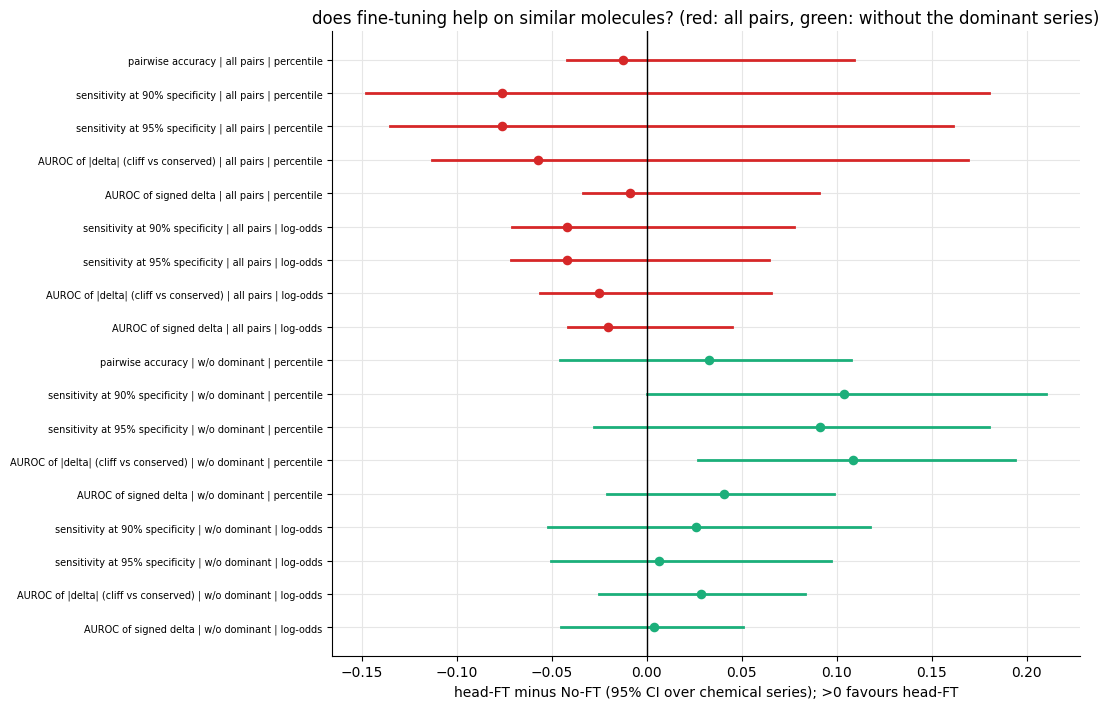

18 comparisons; 1 have an interval that excludes zero:


,noft,ft,diff,lo,hi
label,,,,,
AUROC of |delta| (cliff vs conserved) | w/o dominant | percentile,0.638,0.746,0.108,0.027,0.194


In [6]:
F=CAL[CAL.subset.isin(["all pairs","without the dominant series"])&CAL.metric.isin(["pairwise_acc","sens@90","sens@95","auc_abs","auc_signed"])&~((CAL.metric=="pairwise_acc")&(CAL.scale=="log-odds"))].copy()
NM={"pairwise_acc":"pairwise accuracy","sens@90":"sensitivity at 90% specificity","sens@95":"sensitivity at 95% specificity","auc_abs":"AUROC of |delta| (cliff vs conserved)","auc_signed":"AUROC of signed delta"}
F["label"]=F.metric.map(NM)+" | "+F.subset.str.replace("without the dominant series","w/o dominant")+" | "+F.scale
F=F.iloc[::-1].reset_index(drop=True); fig,ax=plt.subplots(figsize=(11,7.2))
for i,r in F.iterrows():
    c=CL if r.subset=="all pairs" else GRN; ax.plot([r.lo,r.hi],[i,i],color=c,lw=2); ax.scatter(r["diff"],i,color=c,s=35,zorder=3)
ax.axvline(0,color=BLK,lw=1); ax.set_yticks(range(len(F))); ax.set_yticklabels(F.label,fontsize=7); ax.set_xlabel("head-FT minus No-FT (95% CI over chemical series); >0 favours head-FT")
ax.set_title("does fine-tuning help on similar molecules? (red: all pairs, green: without the dominant series)"); plt.tight_layout(); plt.show()
sig=F[(F.lo>0)|(F.hi<0)]; print(f"{len(F)} comparisons; {len(sig)} have an interval that excludes zero:"); display(sig[["label","noft","ft","diff","lo","hi"]].round(3).set_index("label"))

## 3. Similar molecules across the five fine-tuning runs
Each seed is an independent fine-tune with the same 300 labels. For each pair, how many of the five seeds rank the active above the inactive? Unanimity in either direction means the seeds agree; it does not mean they are right.

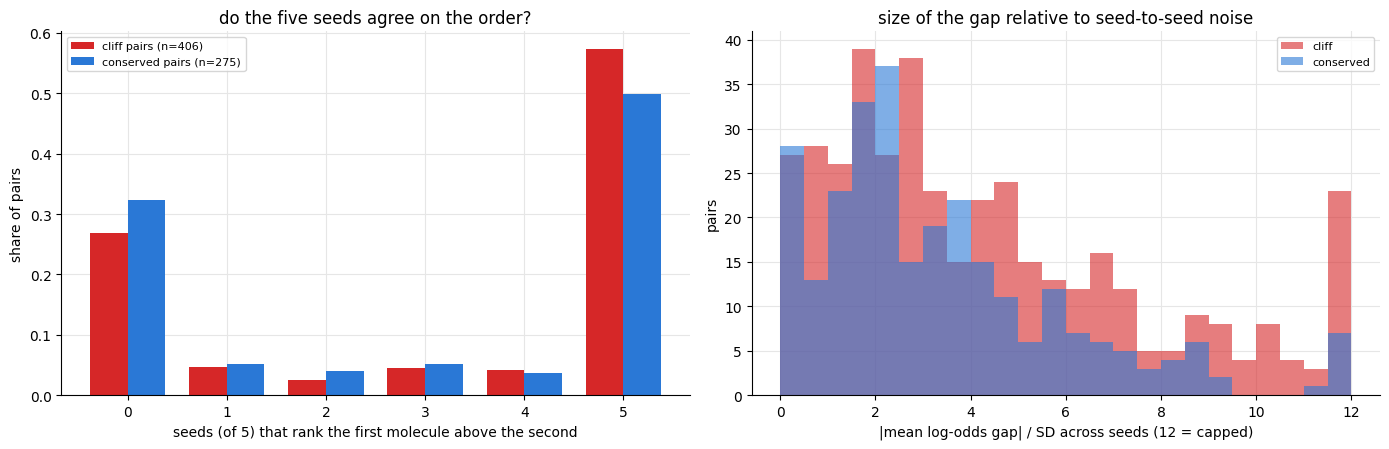

,pairs,share of cliffs
all 5 seeds rank the ACTIVE higher (right),233,0.574
all 5 seeds rank the INACTIVE higher (wrong),109,0.268
"seeds split, ensemble mean says active higher (right)",34,0.084
"seeds split, ensemble mean says inactive higher (wrong)",30,0.074


seeds agree unanimously on 84% of cliffs; of those, 68% are right. Split pairs: 64; ensemble right on 34.
conserved pairs: unanimous either way 82%
cliff: median |gap|/SD across seeds 3.35; share of pairs above 2: 70%
conserved: median |gap|/SD across seeds 2.57; share of pairs above 2: 65%
  all cliffs                   unanimous right 57% | unanimous wrong 27% | split 16%  (n=406)
  without the dominant series  unanimous right 62% | unanimous wrong 26% | split 12%  (n=154)
  dominant series only         unanimous right 55% | unanimous wrong 27% | split 18%  (n=252)


In [7]:
pa=np.stack([S[c].reindex(P.id_a).values for c in SEEDS],1); pb=np.stack([S[c].reindex(P.id_b).values for c in SEEDS],1)
P["votes"]=(pa>pb).sum(1); dl=lg(pa)-lg(pb); P["dl_mean"]=dl.mean(1); P["dl_sd"]=dl.std(1,ddof=1); P["snr"]=np.abs(P.dl_mean)/P.dl_sd.replace(0,np.nan)
CLIFF=P[P.kind=="cliff"].copy(); CTRL=P[P.kind=="conserved"].copy()
fig,axes=plt.subplots(1,2,figsize=(14,4.6)); w=0.38
vc=CLIFF.votes.value_counts(normalize=True).reindex(range(6)).fillna(0); vk=CTRL.votes.value_counts(normalize=True).reindex(range(6)).fillna(0)
axes[0].bar(np.arange(6)-w/2,vc,w,color=CL,label=f"cliff pairs (n={len(CLIFF)})"); axes[0].bar(np.arange(6)+w/2,vk,w,color=CO,label=f"conserved pairs (n={len(CTRL)})")
axes[0].set_xlabel("seeds (of 5) that rank the first molecule above the second"); axes[0].set_ylabel("share of pairs"); axes[0].legend(fontsize=8); axes[0].set_title("do the five seeds agree on the order?")
axes[1].hist(np.clip(CLIFF.snr.dropna(),0,12),bins=np.linspace(0,12,25),alpha=0.6,color=CL,label="cliff"); axes[1].hist(np.clip(CTRL.snr.dropna(),0,12),bins=np.linspace(0,12,25),alpha=0.6,color=CO,label="conserved")
axes[1].set_xlabel("|mean log-odds gap| / SD across seeds (12 = capped)"); axes[1].set_ylabel("pairs"); axes[1].legend(fontsize=8); axes[1].set_title("size of the gap relative to seed-to-seed noise")
plt.tight_layout(); plt.show()
un=CLIFF[(CLIFF.votes==5)|(CLIFF.votes==0)]; sp_=CLIFF[CLIFF.votes.between(1,4)]
tab=pd.DataFrame({"pairs":[len(un[un.votes==5]),len(un[un.votes==0]),len(sp_[sp_.dl_mean>0]),len(sp_[sp_.dl_mean<=0])]},index=["all 5 seeds rank the ACTIVE higher (right)","all 5 seeds rank the INACTIVE higher (wrong)","seeds split, ensemble mean says active higher (right)","seeds split, ensemble mean says inactive higher (wrong)"]); tab["share of cliffs"]=(tab.pairs/len(CLIFF)).round(3); display(tab)
print(f"seeds agree unanimously on {100*len(un)/len(CLIFF):.0f}% of cliffs; of those, {100*(un.votes==5).mean():.0f}% are right. Split pairs: {len(sp_)}; ensemble right on {int((sp_.dl_mean>0).sum())}.")
print(f"conserved pairs: unanimous either way {100*((CTRL.votes==5)|(CTRL.votes==0)).mean():.0f}%")
for nm_,d_ in [("cliff",CLIFF),("conserved",CTRL)]: print(f"{nm_}: median |gap|/SD across seeds {d_.snr.median():.2f}; share of pairs above 2: {100*(d_.snr>2).mean():.0f}%")
for nm,d in [("all cliffs",CLIFF),("without the dominant series",CLIFF[~CLIFF.big]),("dominant series only",CLIFF[CLIFF.big])]:
    print(f"  {nm:<28} unanimous right {100*(d.votes==5).mean():.0f}% | unanimous wrong {100*(d.votes==0).mean():.0f}% | split {100*d.votes.between(1,4).mean():.0f}%  (n={len(d)})")

## 4. Are similar molecules high or low confidence?
Two kinds of confidence from the fine-tuned model: how much the five seeds vary on a molecule (low variation means confident) and how much the two affinity heads within a model disagree (low disagreement means confident). Similar molecules tend to score high, and confidence depends strongly on the score, so pair members are compared with library compounds **at the same score level** (deciles of each model's own score), not with the whole library.

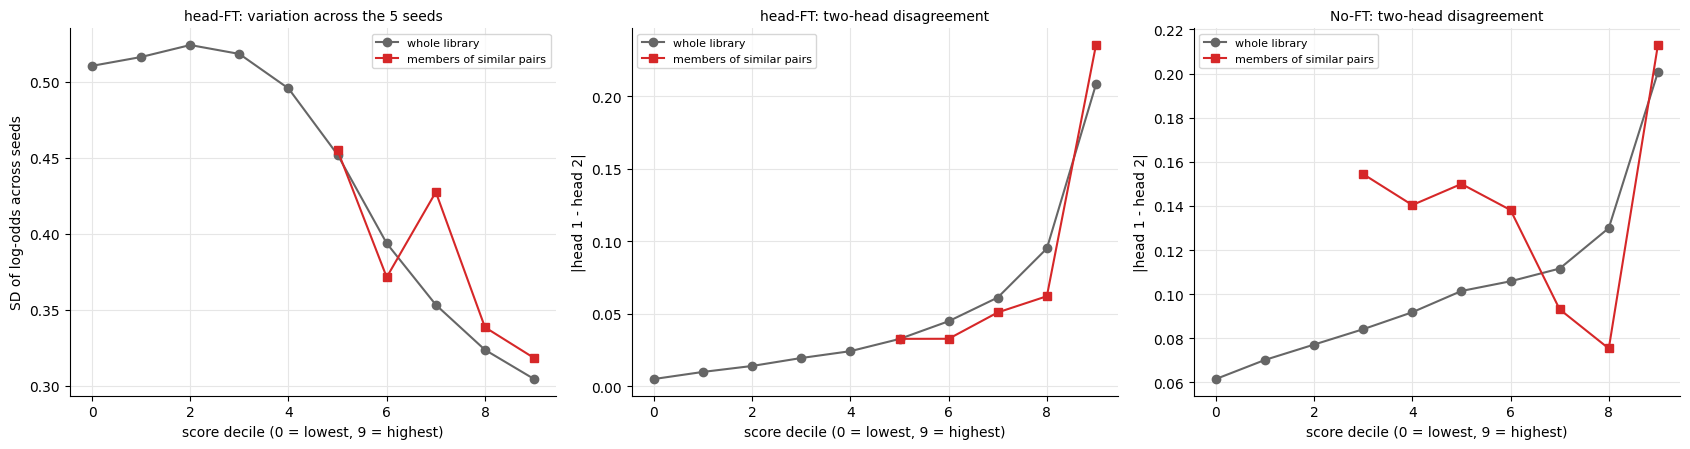

,"library, top score decile","pair members, top score decile",pair members in that decile
measure,,,
head-FT: variation across the 5 seeds,0.304,0.318,271
head-FT: two-head disagreement,0.208,0.235,271
No-FT: two-head disagreement,0.201,0.213,207


share of pair members in the top FT-score decile: 74 % | in the top No-FT decile: 57 %


In [8]:
S["dec_ft"]=pd.qcut(S.ft_mean.rank(method="first"),10,labels=False); S["dec_no"]=pd.qcut(S.noft_p.rank(method="first"),10,labels=False)
isM=S.index.isin(MEM); fig,axes=plt.subplots(1,3,figsize=(17,4.6)); out=[]
for ax,(col,dec,ttl,yl) in zip(axes,[("ft_sd","dec_ft","head-FT: variation across the 5 seeds","SD of log-odds across seeds"),("ft_dis","dec_ft","head-FT: two-head disagreement","|head 1 - head 2|"),("noft_dis","dec_no","No-FT: two-head disagreement","|head 1 - head 2|")]):
    lib=S.groupby(dec)[col].median(); mem=S[isM].groupby(dec)[col].median(); cnt=S[isM].groupby(dec).size()
    ax.plot(lib.index,lib.values,marker="o",color=NEU,label="whole library"); ax.plot(mem.index[cnt.reindex(mem.index)>=5],mem[cnt.reindex(mem.index)>=5].values,marker="s",color=CL,label="members of similar pairs")
    ax.set_xlabel("score decile (0 = lowest, 9 = highest)"); ax.set_ylabel(yl); ax.set_title(ttl,fontsize=10); ax.legend(fontsize=8)
    out.append((ttl,lib.loc[9],mem.loc[9] if 9 in mem.index else np.nan,int(cnt.get(9,0))))
plt.tight_layout(); plt.show()
display(pd.DataFrame(out,columns=["measure","library, top score decile","pair members, top score decile","pair members in that decile"]).round(3).set_index("measure"))
print("share of pair members in the top FT-score decile:",round(100*S[isM].dec_ft.eq(9).mean()),"% | in the top No-FT decile:",round(100*S[isM].dec_no.eq(9).mean()),"%")

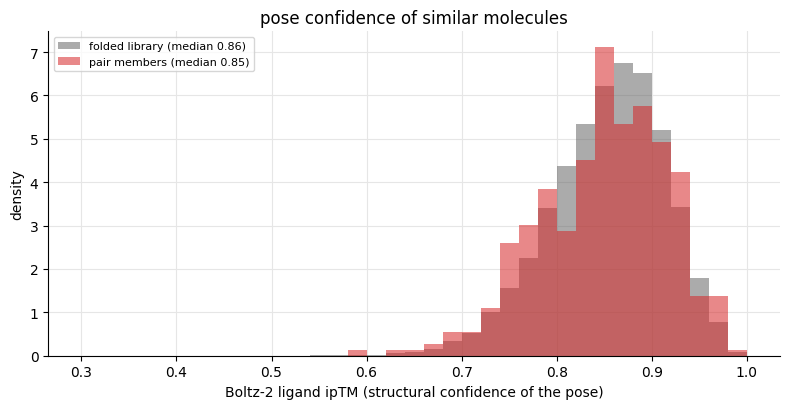

In [9]:
q=pd.read_csv(ROOT/"results/runs/588689/qc.csv"); fig,ax=plt.subplots(figsize=(8,4.2)); b=np.linspace(0.3,1,36)
ax.hist(q.ligand_iptm.dropna(),bins=b,density=True,alpha=0.55,color=NEU,label=f"folded library (median {q.ligand_iptm.median():.2f})"); ax.hist(Mi.ligand_iptm.dropna(),bins=b,density=True,alpha=0.55,color=CL,label=f"pair members (median {Mi.ligand_iptm.median():.2f})")
ax.set_xlabel("Boltz-2 ligand ipTM (structural confidence of the pose)"); ax.set_ylabel("density"); ax.legend(fontsize=8); ax.set_title("pose confidence of similar molecules")
plt.tight_layout(); plt.show()

## Conclusions (target 588689)

**1. Whole library** (49,685 held-out compounds, 396 active). At equal cutoffs head-FT is better on every measure and worse on none. Flagging the top 1% (497 compounds) it finds 125 actives against 67 for No-FT (sensitivity 31.6% vs 16.9%), has 372 false positives against 430 (specificity 99.25% vs 99.13%, precision 25.2% vs 13.5%), and misses 271 actives against 329. The same holds at 0.5%, 2%, 5% and 10% (at 10%, sensitivity 79.3% vs 68.7%). The idea that it discards inactives better but misses more actives does describe the *default p > 0.5 threshold*: head-FT then flags only 200 compounds (No-FT flags 2,062), finding 75 of 396 actives against 190 (missing 321 against 206) with 125 false positives against 1,872 (specificity 99.75% vs 96.2%). That is fine-tuning shifting its probabilities down, a stricter point on a better curve, and it disappears when the two are compared at the same number of flagged compounds.

**2. Similar molecules** (406 cliff pairs whose label flips and 275 conserved pairs, 365 distinct compounds, 114 actives, 94 chemical series; one series holds 62% of the cliffs). Head-FT is not shown to be better or worse than No-FT. Ranking the active above its inactive partner: 0.660 vs 0.672 across all pairs (difference -0.012, 95% CI -0.042 to +0.109) and 0.701 vs 0.669 without the dominant series (+0.032, -0.046 to +0.108; 154 cliffs, 93 series). At each model's own 90% specificity, the share of true cliffs detected in the right direction is 0.14 vs 0.21 (percentile scale) or 0.13 vs 0.17 (log-odds) for all pairs, and 0.25 vs 0.15 or 0.16 vs 0.13 without the dominant series. Of 18 comparisons only one interval excludes zero (AUROC of |delta| without the dominant series, percentile scale, +0.11, +0.03 to +0.19), and it shrinks to +0.03 on the log-odds scale. Both models detect only about 13-25% of true cliffs at 90% specificity. The intervals are wide, so this is an absence of evidence for a difference, not evidence that there is none.

**3. Confidence across the five seeds.** The seeds mostly agree on the order of a similar pair: unanimous on 84% of cliff pairs and 82% of conserved pairs. Agreement is not correctness: 57% of cliffs are unanimously right, 27% unanimously wrong and 16% split, so the unanimous pairs are only 68% right (233 of 342). The gap between the two molecules is more than twice the seed-to-seed spread for about 70% of cliffs. Similar molecules are neither unusually confident nor unusually uncertain for their score: in the top score decile, pair members and library compounds have the same seed variation (0.318 vs 0.304), head-FT two-head disagreement (0.235 vs 0.208), No-FT two-head disagreement (0.213 vs 0.201) and pose confidence (ligand ipTM 0.855 vs 0.859 for the folded library). A raw comparison that ignores score level suggests otherwise (head-FT disagreement 0.17 on pair members against 0.03 across the library), but that is an artefact: 74% of pair members sit in the top head-FT decile, where disagreement is naturally high. None of these confidence measures separates right from wrong calls on similar molecules.

**Bottom line.** Fine-tuning is a better way to find actives in a large library, and the gain comes from ranking chemical series against each other. On near-identical molecules it is neither better nor worse than No-FT, both are weak there, and neither the five seeds' agreement, the two heads' agreement nor the pose confidence tells you which of those calls to trust.

**Caveats.** One target. The similar-molecule set is anchored on held-out actives and dominated by one series. The labels are binary; conserved pairs count as 'no delta' because both are active, though their potency may differ. All five seeds use the default top-300 training set; the balanced-selection variant (notebook 12) was not tested here.